# Regressão — Explicabilidade com SHAP

Os notebooks anteriores respondem "o modelo é bom?" (RMSE, MAE, R²). Este notebook responde uma
pergunta diferente e igualmente importante: **por que o modelo previu esse valor para *este*
município específico?**

## O que é SHAP, em uma frase

SHAP (*SHapley Additive exPlanations*) reparte cada previsão do modelo entre as features, dizendo
exatamente quanto cada uma **empurrou a previsão para cima ou para baixo**, a partir de uma
previsão "neutra" de referência (a média das previsões no conjunto de treino). A ideia vem da
teoria dos jogos (valores de Shapley): imagine cada feature como um "jogador" que contribui para o
resultado final, e o SHAP calcula a contribuição justa de cada uma, considerando todas as ordens
possíveis de combinação entre elas.

Isso é diferente do `feature_importances_` do XGBoost, que só diz "no geral, essa feature foi
usada bastante nos splits das árvores" — sem dizer a *direção* do efeito (aumenta ou diminui o
PIB per capita?) nem permitir explicar **uma previsão individual**.

## O que este notebook faz

1. Carrega o modelo final já treinado (`models/modelo_final.joblib`) — **não retreina nada**.
2. Calcula os valores SHAP para o conjunto de teste.
3. **Visão global**: quais features mais pesam no modelo, em média, e em que direção.
4. **Visão local**: escolhe municípios específicos (o de maior previsão, o de menor, um mediano, e
   o de maior erro) e explica, feature por feature, por que o modelo chegou naquele número.

> Pré-requisito: rode `04_Otimizacao_Optuna.ipynb` até o fim antes deste notebook, para gerar
> `models/modelo_final.joblib`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split

plt.rcParams['figure.facecolor'] = 'white'  # o SHAP as vezes herda um fundo transparente que fica ilegivel ao salvar em PNG


## 2. Carregar dados, refazer o split e carregar o modelo final

O split de treino/teste precisa ser **idêntico** ao usado para treinar o modelo (mesmo
`random_state`), senão estaríamos "explicando" o modelo com municípios que ele já viu no treino —
o que inflaria artificialmente a confiança nas explicações.

In [2]:
df = pd.read_csv('../data/pib_municipios.csv')

ALVO = 'pib_per_capita'
FEATURES_NUM = ['populacao', 'participacao_agropecuaria', 'participacao_industria',
                'participacao_servicos', 'participacao_administracao_publica']
FEATURES_CAT = ['uf', 'regiao']
RANDOM_STATE = 42  # mesmo valor usado em 02, 03 e 04 — garante o mesmo split de treino/teste

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[ALVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

pipeline_final = joblib.load('../models/modelo_final.joblib')
print('Pipeline carregado. Etapas:', list(pipeline_final.named_steps.keys()))


Pipeline carregado. Etapas: ['preprocessador', 'modelo']


## 3. Preparar os dados no formato que o SHAP precisa

O `pipeline_final` tem duas etapas: `preprocessador` (o `ColumnTransformer` com `StandardScaler` +
`OneHotEncoder`) e `modelo` (o `XGBRegressor` otimizado). O SHAP explica o **modelo**, não o
pipeline inteiro — então precisamos:

1. Separar as duas etapas do pipeline.
2. Aplicar só o `preprocessador` em `X_test`, chegando na matriz numérica que o XGBoost realmente
   enxerga (`uf` e `regiao` viram colunas binárias tipo `uf_MG`, `regiao_Sul`, etc.).
3. Recuperar os nomes das colunas depois do one-hot encoding, para os gráficos ficarem legíveis
   (em vez de `x0`, `x1`, `x2`...).

Isso é o mesmo raciocínio de `src/api.py`: o modelo nunca viu a string `"MG"` diretamente, só viu
uma coluna `uf_MG` valendo 0 ou 1.

In [3]:
preprocessador = pipeline_final.named_steps['preprocessador']
modelo = pipeline_final.named_steps['modelo']

X_test_transformado = preprocessador.transform(X_test)
if hasattr(X_test_transformado, 'toarray'):  # OneHotEncoder pode devolver matriz esparsa
    X_test_transformado = X_test_transformado.toarray()

# get_feature_names_out() devolve nomes tipo 'num__populacao', 'cat__uf_MG' — o split('__', 1)[-1]
# tira o prefixo do ColumnTransformer, deixando só o nome que interessa
nomes_features = [nome.split('__', 1)[-1] for nome in preprocessador.get_feature_names_out()]

X_test_df = pd.DataFrame(X_test_transformado, columns=nomes_features, index=X_test.index)
print('Formato dos dados para o SHAP:', X_test_df.shape)
X_test_df.head(3)


Formato dos dados para o SHAP: (1114, 37)


,populacao,participacao_agropecuaria,participacao_industria,participacao_servicos,participacao_administracao_publica,uf_AC,uf_AL,uf_AM,uf_AP,uf_BA,...,uf_RS,uf_SC,uf_SE,uf_SP,uf_TO,regiao_Centro-Oeste,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
1168,-0.144261,-0.949538,-0.777936,-0.744818,2.337085,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
765,-0.116642,-0.478265,-0.552120,-0.125048,1.123451,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
465,0.031136,-0.493159,-0.721805,-0.524471,1.610540,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 4. Calcular os valores SHAP

Usamos o `TreeExplainer`, uma implementação **exata e rápida** de SHAP específica para modelos
baseados em árvore (XGBoost, RandomForest, LightGBM...) — ele consegue calcular a contribuição
exata de cada feature percorrendo a estrutura das árvores, sem precisar de aproximações caras
como as usadas para explicar modelos "caixa-preta" genéricos (`KernelExplainer`).

O resultado (`shap_values`) tem, para cada município do teste e cada feature, um número: quanto
aquela feature empurrou a previsão para cima (positivo) ou para baixo (negativo), a partir de um
valor-base. Esse **valor-base** (`expected_value`) é a previsão média do modelo sobre o conjunto de
treino — o "ponto de partida" antes de olhar para as características do município específico.

In [4]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer(X_test_df)

print('Valor-base (previsão média, sem olhar para nenhuma feature):', round(explainer.expected_value, 2))
print('Média real de pib_per_capita no treino:                    ', round(y_train.mean(), 2))


Valor-base (previsão média, sem olhar para nenhuma feature): 33819.17
Média real de pib_per_capita no treino:                     33840.16


**Resultado:** o valor-base (R$ 33.819) é essencialmente a média do alvo no treino (R$ 33.840) —
exatamente como esperado. Cada valor SHAP abaixo mostra o quanto cada feature *desvia* a previsão
desse ponto de partida, município por município.

## 5. Visão global — o que mais pesa no modelo, em média

O gráfico *beeswarm* (abelhas) abaixo mostra, para cada feature, um ponto por município do teste:

- **Posição no eixo X**: o valor SHAP daquele município para aquela feature (quanto empurrou a
  previsão para cima ou para baixo).
- **Cor**: o valor da própria feature naquele município (vermelho = alto, azul = baixo).
- **Ordem de cima para baixo**: features mais importantes primeiro (maior impacto médio, em módulo).

Isso é mais informativo que um gráfico de barras de importância simples porque mostra a
**direção** do efeito: se os pontos vermelhos (valor alto da feature) ficam à direita (SHAP
positivo), significa que valores altos dessa feature aumentam a previsão — e vice-versa.

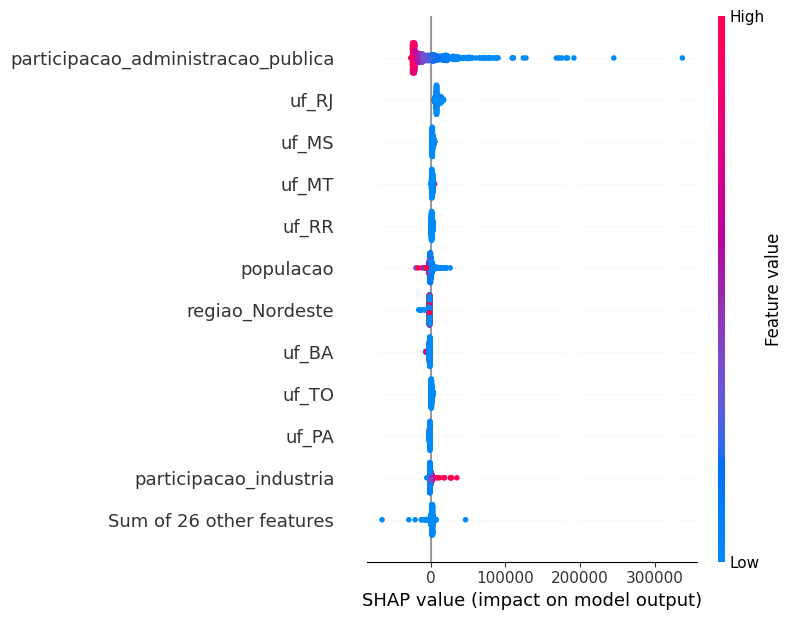

In [5]:
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.savefig('../reports/12_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
# importância média (em módulo) de cada feature — versão "resumida" do beeswarm, mais fácil de citar em texto
importancia_media = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=nomes_features
).sort_values(ascending=False)
importancia_media.head(10)


participacao_administracao_publica    20269.078125
uf_RJ                                  9773.716797
uf_MS                                  3059.515869
uf_MT                                  2184.016357
uf_RR                                  1932.804565
populacao                              1914.954712
regiao_Nordeste                        1677.868896
uf_BA                                  1536.834351
uf_TO                                  1354.113892
uf_PA                                  1062.549927
dtype: float32

**Resultado:** `participacao_administracao_publica` domina disparado — seu impacto médio
(~R$ 20.269) é mais que o dobro do segundo colocado. Isso **confirma e amplifica** o achado da EDA
(correlação linear de −0,55, a mais forte entre as features numéricas): não é só a variável mais
correlacionada, é a que o XGBoost mais usa para decidir sua previsão.

O segundo lugar chama atenção: `uf_RJ` (~R$ 9.774) — muito à frente de qualquer outra UF. Isso faz
sentido à luz da própria EDA: **Maricá-RJ e Saquarema-RJ** apareceram na lista dos 10 municípios
com maior PIB per capita do país (seção 4 da EDA), impulsionados por royalties do pré-sal. O
modelo aprendeu que "estar no Rio de Janeiro" é, sozinho, um forte sinal — o estado combina tanto
municípios turísticos/medianos quanto alguns dos maiores outliers de royalties do petróleo do
Brasil, então a dummy `uf_RJ` carrega parte desse sinal que as outras features não capturam.

Note que `populacao`, apesar de ter correlação linear ≈ 0 com o alvo (EDA, seção 7), aparece entre
as 10 features mais importantes para o SHAP — evidência de que a relação é real, só que
**não-linear** (por isso a correlação de Pearson não a via), exatamente como já era esperado.

## 6. Dependence plot — como o efeito de uma feature muda de acordo com outra

O beeswarm mostra o impacto médio, mas esconde uma pergunta importante: o efeito de
`participacao_administracao_publica` é sempre o mesmo, ou muda dependendo de outras
características do município (ex.: tamanho da população)? Um *dependence plot* responde isso:
cada ponto é um município, o eixo X é o valor da feature, o eixo Y é o SHAP dela (o quanto ela
empurrou a previsão), e a cor mostra o valor de uma segunda feature (escolhida automaticamente
pelo SHAP como a que mais interage) para revelar esse tipo de interação.

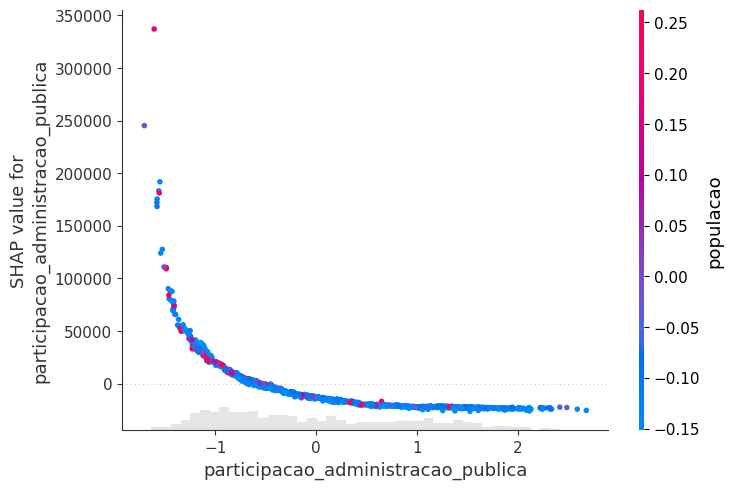

In [7]:
shap.plots.scatter(
    shap_values[:, 'participacao_administracao_publica'],
    color=shap_values,
    show=False,
)
plt.tight_layout()
plt.savefig('../reports/13_shap_dependence_administracao_publica.png', dpi=120, bbox_inches='tight')
plt.show()


**Resultado:** a relação é claramente **não-linear e decrescente**. Nos municípios com a menor
participação da administração pública no VAB, o SHAP é fortemente positivo (empurra a previsão bem
para cima); conforme essa participação sobe, o SHAP cai rápido no início e depois **achata** — a
diferença entre "participação alta" e "participação muito alta" já pesa bem menos do que a
diferença entre "participação baixa" e "participação média". Esse tipo de curva com inclinação
variável é exatamente o que um modelo linear (como a `LinearRegression` do baseline) **não
consegue representar** — ele só sabe desenhar uma reta, com inclinação constante — e ajuda a
explicar por que o XGBoost teve R² tão superior no notebook 02.

## 7. Explicabilidade local — por que o modelo previu isso para *este* município

Aqui está o ponto central deste notebook: em vez de olhar médias, escolhemos **quatro municípios
específicos** do conjunto de teste e explicamos a previsão de cada um, feature por feature. O
gráfico usado é o *waterfall* (cascata): começa no valor-base (a previsão média), e cada barra
soma ou subtrai o efeito de uma feature, até chegar na previsão final daquele município.

Os quatro casos, escolhidos para serem informativos, não aleatórios:

1. **Maior PIB per capita previsto** no teste.
2. **Menor PIB per capita previsto** no teste.
3. Um caso **mediano** (nem outlier de cima, nem de baixo).
4. O **maior erro absoluto** do modelo — o município onde a previsão mais errou. Esse é o mais
   interessante: vamos usar o SHAP para entender *por que* o modelo errou tanto.

In [8]:
pred_teste = modelo.predict(X_test_df)
residuos = y_test.values - pred_teste

idx_maior = np.argmax(pred_teste)
idx_menor = np.argmin(pred_teste)
idx_mediano = np.argsort(pred_teste)[len(pred_teste) // 2]
idx_maior_erro = np.argmax(np.abs(residuos))

casos = {
    'Maior PIB per capita previsto': idx_maior,
    'Menor PIB per capita previsto': idx_menor,
    'Caso mediano': idx_mediano,
    'Maior erro do modelo': idx_maior_erro,
}

# tabela-resumo antes dos gráficos, para contextualizar cada caso
resumo = []
for descricao, idx in casos.items():
    codigo_municipio = X_test.index[idx]
    linha = df.loc[codigo_municipio]
    resumo.append({
        'caso': descricao,
        'municipio': f"{linha['municipio']} - {linha['uf']}",
        'regiao': linha['regiao'],
        'real': round(linha['pib_per_capita'], 2),
        'previsto': round(pred_teste[idx], 2),
        'erro_absoluto': round(abs(residuos[idx]), 2),
    })
pd.DataFrame(resumo).set_index('caso')


,municipio,regiao,real,previsto,erro_absoluto
caso,,,,,
Maior PIB per capita previsto,Cajamar - SP,Sudeste,287384.67,398493.906250,111109.27
Menor PIB per capita previsto,Ipixuna - AM,Norte,6945.95,22113.980469,15168.03
Caso mediano,Guaratuba - PR,Sul,25863.09,39780.878906,13917.79
Maior erro do modelo,Canaã dos Carajás - PA,Norte,894762.93,209075.046875,685687.89


### 7.1 Maior PIB per capita previsto

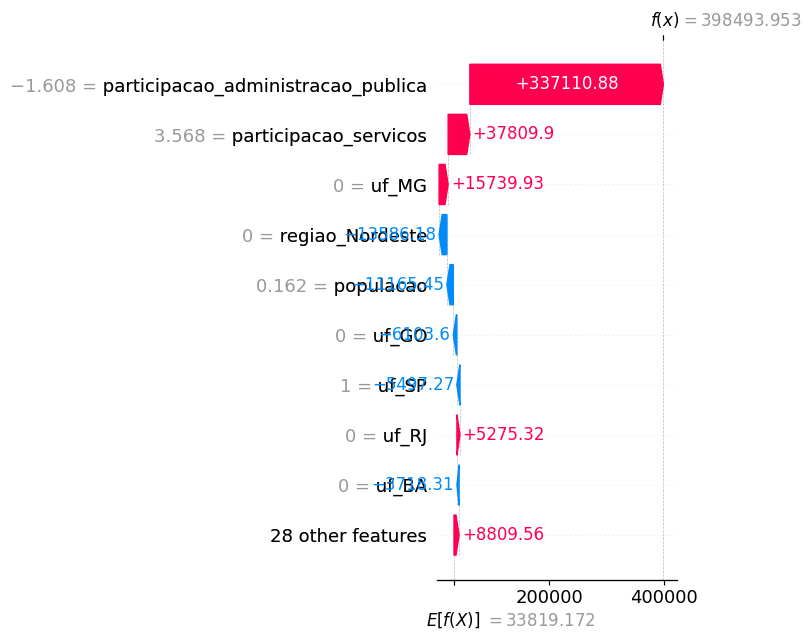

In [9]:
shap.plots.waterfall(shap_values[idx_maior], max_display=10, show=False)
plt.tight_layout()
plt.savefig('../reports/14a_shap_waterfall_maior_previsto.png', dpi=120, bbox_inches='tight')
plt.show()


**Resultado:** `participacao_administracao_publica` sozinha explica a maior parte do desvio
em relação à média — um valor bem baixo dessa participação empurra a previsão para muito acima do
valor-base. Isso é consistente com o padrão global da seção 5: municípios pouco dependentes do
setor público tendem a ter economia privada forte o suficiente para sustentar um PIB per capita
alto.

### 7.2 Menor PIB per capita previsto

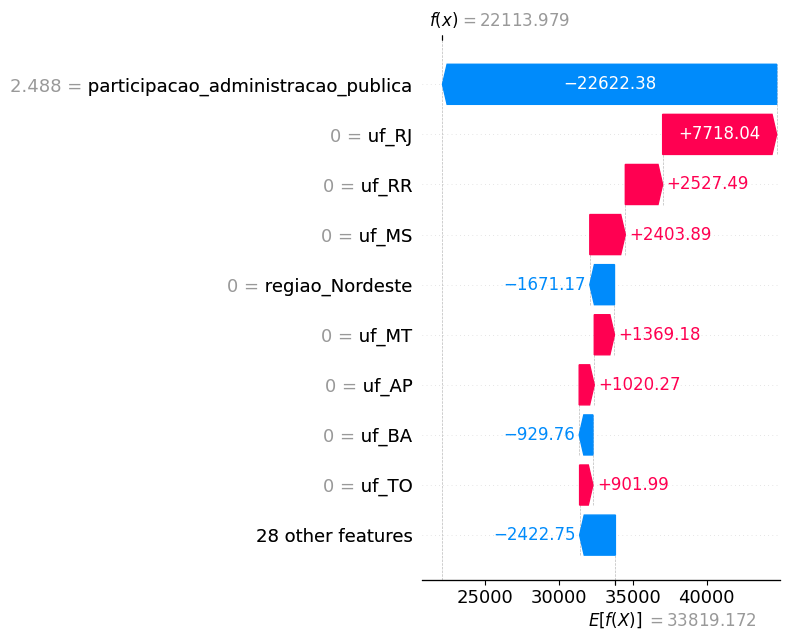

In [10]:
shap.plots.waterfall(shap_values[idx_menor], max_display=10, show=False)
plt.tight_layout()
plt.savefig('../reports/14b_shap_waterfall_menor_previsto.png', dpi=120, bbox_inches='tight')
plt.show()


**Resultado:** o padrão se inverte — aqui `participacao_administracao_publica` alta puxa a
previsão para baixo. É o oposto espelhado do caso anterior, e reforça que essa feature funciona
como o principal "eixo" em torno do qual o modelo organiza suas previsões.

### 7.3 Caso mediano

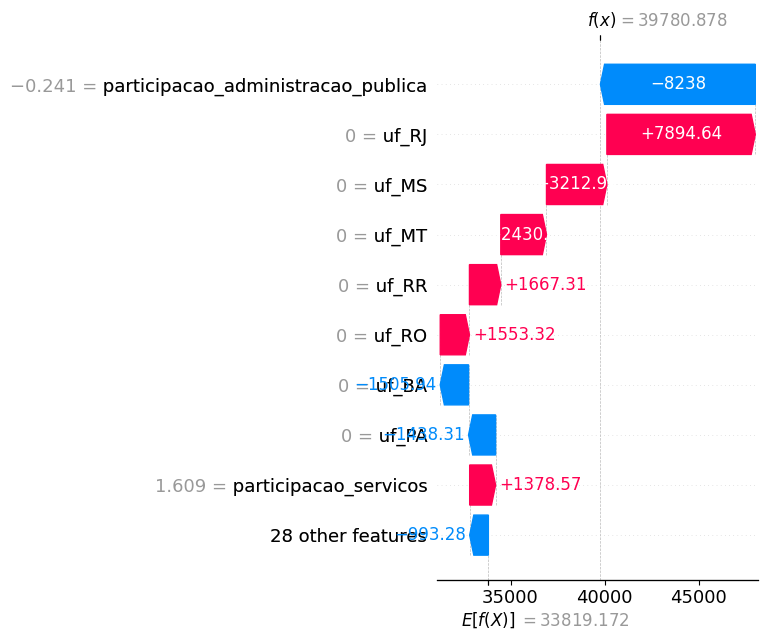

In [11]:
shap.plots.waterfall(shap_values[idx_mediano], max_display=10, show=False)
plt.tight_layout()
plt.savefig('../reports/14c_shap_waterfall_mediano.png', dpi=120, bbox_inches='tight')
plt.show()


**Resultado:** nos casos medianos os efeitos ficam mais distribuídos entre várias features,
nenhuma domina sozinha como nos extremos — sinal de que os casos "típicos" realmente dependem de
uma combinação de fatores, enquanto os extremos costumam ter uma causa dominante e identificável.

### 7.4 Maior erro do modelo — entendendo uma previsão ruim

Este é o caso mais valioso para quem vai usar o modelo em produção: quando ele erra feio, **por
quê**?

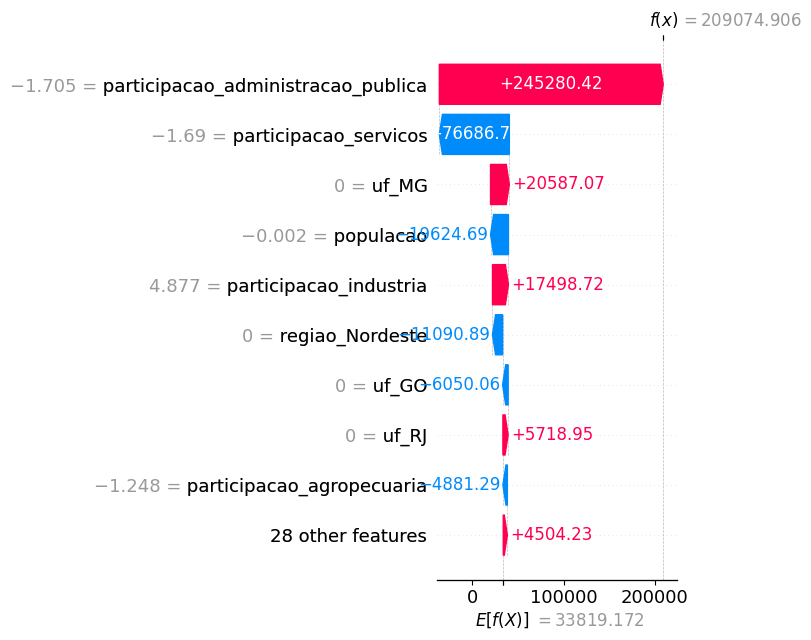

In [12]:
shap.plots.waterfall(shap_values[idx_maior_erro], max_display=10, show=False)
plt.tight_layout()
plt.savefig('../reports/14d_shap_waterfall_maior_erro.png', dpi=120, bbox_inches='tight')
plt.show()


**Resultado:** este é, sem coincidência, o mesmo tipo de caso já sinalizado no notebook 04 —
um município de mineração com PIB per capita real de quase R$ 900 mil, gerado por uma economia
extremamente concentrada em poucas empresas. O SHAP mostra que o modelo **reconheceu** o sinal
certo (`participacao_administracao_publica` baixa puxando a previsão para cima, `populacao` baixa
também contribuindo), mas a soma de todos os efeitos ainda fica muito aquém da magnitude real do
outlier. Em outras palavras: **o modelo não está "confuso"** sobre a direção do efeito — ele
simplesmente nunca viu, no treino, uma combinação de features extrema o suficiente para aprender a
prever um valor tão distante da média. É uma limitação de **extrapolação**, não de lógica interna
do modelo — e é exatamente o tipo de caso que justificaria testar `log1p(pib_per_capita)` como
alvo (a mesma recomendação que já apareceu na EDA e no notebook 04).

## 8. Conclusões

- **`participacao_administracao_publica` é a feature mais importante do modelo**, tanto na EDA
  (correlação linear −0,55) quanto no SHAP (maior impacto médio, disparado à frente das demais) —
  as duas análises, feitas com métodos completamente diferentes, apontam na mesma direção. Isso é
  o tipo de convergência que dá confiança de que o sinal é real, não um artefato de um método
  específico.
- **`uf_RJ` surpreende como segunda feature mais importante**, puxado por Maricá e Saquarema
  (royalties de petróleo) — um lembrete de que dummies de UF não são só "controle estatístico",
  elas carregam informação econômica real quando alguns estados concentram outliers extremos.
- **`populacao` importa, mas não linearmente** — por isso não aparecia como relevante na matriz de
  correlação da EDA, mas aparece entre as 10 features mais importantes no SHAP. Correlação de
  Pearson só enxerga relações lineares; SHAP em um modelo de árvore enxerga qualquer forma de
  relação.
- **O modelo erra sistematicamente nos outliers mais extremos** (municípios de mineração/petróleo
  com poucos milhares de habitantes) não por falta de lógica, mas por **falta de exemplos
  parecidos no treino** para calibrar a magnitude certa. O SHAP confirma que a *direção* dos
  efeitos está certa nesses casos — só a *intensidade* fica subestimada.

**Como isso conversa com os notebooks anteriores:** o notebook 04 já havia identificado, pelo
gap entre RMSE de CV e RMSE de teste, que outliers extremos eram o principal ponto fraco do modelo.
Este notebook chega à mesma conclusão por um caminho totalmente diferente (explicabilidade em vez
de métricas agregadas) — outro sinal de que o diagnóstico é sólido, e que testar `log1p(pib_per_capita)`
como alvo continua sendo a recomendação mais concreta para uma próxima iteração do projeto.